# 01 · What rheology measures

**Question.** A ketchup bottle, a drilling mud and a polymer melt all have "a viscosity" on their data
sheet. Why is one number not enough - and which number matters for a given process?

Rheology describes how materials flow and deform. This notebook introduces the central quantities: shear
stress, shear rate and viscosity; the shear rates of real processes; and two dimensionless numbers that
decide whether a material behaves like a liquid or a solid.

**What you will learn**
- define shear stress, shear rate and viscosity
- estimate the shear rates of real processes
- explain why one viscosity number is not enough for most fluids
- use the Deborah and Weissenberg numbers

**Before you start:** notebook 00; basic mechanics (force, stress)  ·  **Time:** about 45 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Simple shear
A layer of fluid of thickness $h$ between a fixed plate and a plate moving at speed $V$ is sheared at the
**shear rate** $\dot\gamma = V/h$ (units 1/s). The force $F$ per plate area $A$ is the **shear stress** $\tau = F/A$ (Pa).
Their ratio is the **viscosity** $\eta = \tau/\dot\gamma$ (Pa·s). For a Newtonian fluid (water, oils, honey) $\eta$ is a
constant; for most engineering fluids it depends on the shear rate.

In [2]:
fluids = {"water": 1.0e-3, "olive oil": 0.08, "glycerol": 1.4, "honey": 10.0}   # Pa s, about 20 degC
V, h, A = 0.1, 1e-3, 0.01                     # 0.1 m/s, 1 mm film, 10 cm x 10 cm plate
rate = V / h
for name, mu in fluids.items():
    print(f"{name:<10}: viscosity {mu:8.4g} Pa s -> stress {mu*rate:9.3g} Pa, force on the plate {mu*rate*A:8.3g} N")

water     : viscosity    0.001 Pa s -> stress       0.1 Pa, force on the plate    0.001 N
olive oil : viscosity     0.08 Pa s -> stress         8 Pa, force on the plate     0.08 N
glycerol  : viscosity      1.4 Pa s -> stress       140 Pa, force on the plate      1.4 N
honey     : viscosity       10 Pa s -> stress     1e+03 Pa, force on the plate       10 N


## Shear rates of real processes
Each process shears a fluid at a characteristic rate. Rough estimates (velocity divided by a length):

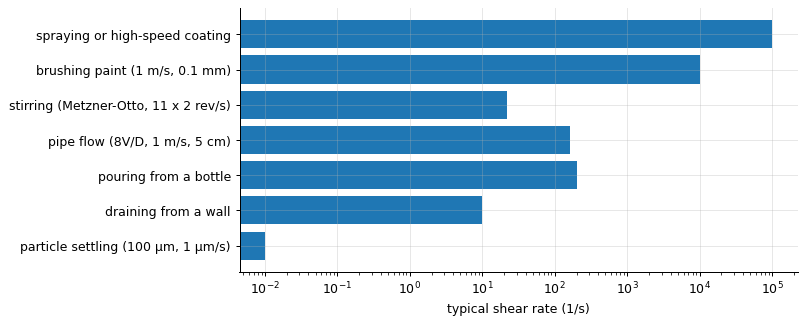

particle settling (100 µm, 1 µm/s)             0.01 1/s -> xanthan viscosity      34.8 Pa s
draining from a wall                             10 1/s -> xanthan viscosity     0.967 Pa s
pouring from a bottle                           200 1/s -> xanthan viscosity     0.104 Pa s
pipe flow (8V/D, 1 m/s, 5 cm)                   160 1/s -> xanthan viscosity     0.123 Pa s
stirring (Metzner-Otto, 11 x 2 rev/s)            22 1/s -> xanthan viscosity     0.536 Pa s
brushing paint (1 m/s, 0.1 mm)                1e+04 1/s -> xanthan viscosity   0.00743 Pa s
spraying or high-speed coating                1e+05 1/s -> xanthan viscosity   0.00297 Pa s


In [3]:
processes = {
    "particle settling (100 µm, 1 µm/s)": 1e-6 / 100e-6,
    "draining from a wall": 1e-2 / 1e-3,
    "pouring from a bottle": 1.0 / 5e-3,
    "pipe flow (8V/D, 1 m/s, 5 cm)": 8 * 1.0 / 0.05,
    "stirring (Metzner-Otto, 11 x 2 rev/s)": 11 * 2.0,
    "brushing paint (1 m/s, 0.1 mm)": 1.0 / 1e-4,
    "spraying or high-speed coating": 1e5,
}
names, rates = list(processes), np.array(list(processes.values()))
plt.figure(figsize=(8, 3.8)); plt.barh(names, rates); plt.xscale("log")
plt.xlabel("typical shear rate (1/s)"); plt.show()
eta_x = models.viscosity("carreau", rates, 35.0, 0.002, 12.0, 0.25)   # the xanthan solution of notebook 00
for n_, r_, e_ in zip(names, rates, eta_x):
    print(f"{n_:<40} {r_:10.3g} 1/s -> xanthan viscosity {e_:9.3g} Pa s")

The rates span about seven decades, and over that range the xanthan solution's viscosity changes by a
factor of about ten thousand: thick at rest (it keeps particles suspended), thin when pumped or sprayed. A single
"viscosity" is meaningless for such a fluid unless the shear rate is stated - **measure at the shear rates
of your process**.

## Liquid or solid? The Deborah number
Many materials remember their shape for a characteristic **relaxation time** $\lambda$. The Deborah number
compares it with the time scale of the observation, $De = \lambda / t_{obs}$: for $De \ll 1$ the material flows like a
liquid, for $De \gg 1$ it responds like a solid.

In [4]:
cases = [("silicone putty bouncing (contact 1 ms)", 1.0, 1e-3),
         ("silicone putty left on a table (1 h)", 1.0, 3600.0),
         ("polymer melt filling a mould (1 s)", 0.5, 1.0),
         ("glacier ice flowing over a century", 1e8, 3e9),
         ("water in a pipe (1 s)", 1e-12, 1.0)]
for name, lam, t in cases:
    De = lam / t
    print(f"{name:<40} De = {De:9.2g} -> {'solid-like' if De > 1 else 'liquid-like' if De < 0.1 else 'viscoelastic'}")

silicone putty bouncing (contact 1 ms)   De =     1e+03 -> solid-like
silicone putty left on a table (1 h)     De =   0.00028 -> liquid-like
polymer melt filling a mould (1 s)       De =       0.5 -> viscoelastic
glacier ice flowing over a century       De =     0.033 -> liquid-like
water in a pipe (1 s)                    De =     1e-12 -> liquid-like


## Inside the algorithm: the Newtonian torque on a cone and on plates
The torque is the stress integrated over the plate, $M = \int_0^R \tau(r)\,2\pi r^2\,dr$. For a cone the stress is
uniform; for plates it grows with $r$ because the shear rate does:

In [5]:
from scipy import integrate
mu, R_, h_, th_, om_ = 1.0, 0.025, 1e-3, np.radians(1.0), 2.0
M_cone = integrate.quad(lambda r: mu * om_ / th_ * 2 * np.pi * r**2, 0, R_)[0]
M_plates = integrate.quad(lambda r: mu * om_ * r / h_ * 2 * np.pi * r**2, 0, R_)[0]
print(f"cone:   M = {M_cone:.6e} N m, formula 2 pi R^3 mu omega/(3 theta) = {2*np.pi*R_**3*mu*om_/(3*th_):.6e}")
print(f"plates: M = {M_plates:.6e} N m, formula pi R^4 mu omega/(2 h)      = {np.pi*R_**4*mu*om_/(2*h_):.6e}")

cone:   M = 3.750000e-03 N m, formula 2 pi R^3 mu omega/(3 theta) = 3.750000e-03
plates: M = 1.227185e-03 N m, formula pi R^4 mu omega/(2 h)      = 1.227185e-03


The same putty is a bouncing solid or a slowly spreading liquid depending on how fast it is deformed.
In a steady flow, the analogous **Weissenberg number** $Wi = \lambda\dot\gamma$ measures how strongly the flow
stretches the material's microstructure; elastic effects (notebooks 07-11) become important when $Wi \gtrsim 1$.

## Exercises
1. Water and a power-law fluid with $n$ = 0.5 flow at a mean velocity of 2 m/s in a 5 cm pipe. The wall shear
   rate of a Newtonian fluid is $8V/D$; for a power-law fluid it is $(3n + 1)/(4n) \cdot 8V/D$ (notebook 02). By
   how much does shear thinning increase the wall shear rate?
2. A polymer melt with relaxation time 0.5 s is extruded through a 1 mm die at 0.5 m/s. Estimate the shear
   rate, the Weissenberg number and the Deborah number (residence time in a 20 mm die). Would you expect
   elastic effects such as die swell?
3. **Implement it yourself:** write `wall_shear_rate(V, D, n=1.0)` for pipe flow and use it to make a table of wall shear rates for velocities 0.1-3 m/s in a 5 cm pipe, for n = 1, 0.6 and 0.3.